# 🧠 Notebook-02: MLP from Scratch – Das Innenleben neuronaler Netze
**KI Advanced · IA1017000 · HfPolBW**

---

**Session:** S 1.3 – Neuronale Netze & Deep Learning
**Ziel:** Das Innenleben neuronaler Netze verstehen – von der Mathematik bis zum laufenden Modell.
**Dauer:** ~30 Minuten

---

| Teil | Inhalt | Kernfrage |
|------|--------|-----------|
| **1** | Aktivierungsfunktionen visualisieren | Warum braucht ein Neuron eine Aktivierungsfunktion? |
| **2** | Einzel-Neuron: Forward Pass nachrechnen | Wie rechnet ein einzelnes Neuron? |
| **3** | MLP from Scratch (NumPy) | Wie lernt ein Netz ohne sklearn? |
| **4** | Gradient Descent & Lernrate | Wie findet das Netz das Minimum? |
| **5** | Overfitting demonstrieren | Wann lernt ein Netz zu viel? |
| **6** | 🚔 Challenge: Deepfake-Erkennung | Echte Bilder vs. KI-generierte Fakes |

---

> ### 📌 Wie benutze ich dieses Notebook?
>
> Jede **Code-Zelle** ist vollständig kommentiert — Sie müssen keinen Code schreiben, nur lesen, ausführen und beobachten.
>
> **Alles ausführen:** Menü → *Runtime → Run all*

---

> ### 🔗 Verbindung zu S1.2 / Notebook-01
>
> In Notebook-01 haben wir ein MLP mit sklearn trainiert und die **Loss-Kurve** gesehen — sie sank, das Modell lernte.
> Jetzt öffnen wir die Black Box: Warum sinkt die Loss-Kurve? Was passiert in jeder Epoche?
> Die Antwort: **Backpropagation** und **Gradient Descent** — die beiden Mechanismen hinter jedem neuronalen Netz.


---
## ⚙️ Setup – Bibliotheken laden

Wir laden dieselben Werkzeugkästen wie in Notebook-01, plus `gridspec` für komplexere Diagramm-Layouts.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SETUP: Alle benötigten Bibliotheken laden.
# Muss immer als erstes ausgeführt werden.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np                          # Mathematik, Matrizen, Zufallszahlen
import pandas as pd                         # Tabellen (DataFrames)
import matplotlib.pyplot as plt             # Diagramme
import matplotlib.gridspec as gridspec      # Komplexe Diagramm-Layouts
import warnings; warnings.filterwarnings('ignore')

# sklearn-Komponenten
from sklearn.datasets import make_classification   # Synthetische Datensätze erzeugen
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier   # Zum Vergleich mit unserer Impl.
from sklearn.metrics import f1_score, accuracy_score, classification_report

# ── Farbpalette (identisch mit NB-01) ────────────────────────────────────────
C = {
    'navy':  '#001E46', 'blue1': '#0D3761', 'blue2': '#1A4E8A',
    'ice':   '#4FC3F7', 'orange':'#ED7D31', 'green': '#52B788',
    'teal':  '#00B4D8', 'lgray': '#B0C4DE', 'white': '#FFFFFF',
    'purple':'#9B59B6', 'gold':  '#FFC300', 'red':   '#E74C3C'
}

# ── Dunkles Diagramm-Design ───────────────────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': C['navy'], 'axes.facecolor':  C['blue1'],
    'axes.edgecolor':   C['lgray'],'axes.labelcolor': C['lgray'],
    'xtick.color':      C['lgray'],'ytick.color':     C['lgray'],
    'text.color':       C['white'],'grid.color':      '#1A4E8A',
    'grid.alpha': 0.4, 'font.size': 11
})

print('✅  Setup OK – alle Bibliotheken geladen')


✅  Setup OK – alle Bibliotheken geladen


---
## Teil 1 – Aktivierungsfunktionen: Das Herzstück jedes Neurons

### 🤔 Was ist eine Aktivierungsfunktion – und warum braucht man sie?

Stellen Sie sich ein Neuron als einfachen Schalter vor. Ohne Aktivierungsfunktion würde es nur eine
gewichtete Summe berechnen — das wäre nichts anderes als lineare Algebra.
Das Problem: Lineare Gleichungen können nur lineare Muster erkennen.

Die Aktivierungsfunktion macht das Neuron **nicht-linear** — und damit erst fähig, komplexe
Muster zu lernen (Kurven, Entscheidungsgrenzen, verschachtelte Muster).

> 💡 **Analogie:** Ein Neuron ohne Aktivierungsfunktion ist wie ein Lichtdimmer, der nur
> proportional heller wird. Mit Aktivierungsfunktion kann es gezielt entscheiden: feuern oder nicht.

### Die vier wichtigsten Aktivierungsfunktionen

| Funktion | Ausgabebereich | Haupteinsatz | Problem |
|----------|---------------|--------------|---------|
| **Sigmoid** | (0, 1) | Ausgabeschicht (Wahrscheinlichkeit) | Vanishing Gradient |
| **Tanh** | (−1, 1) | Versteckte Schichten (veraltet) | Auch Vanishing Gradient |
| **ReLU** | [0, ∞) | Standard in versteckten Schichten | Dying ReLU |
| **Leaky ReLU** | (−∞, ∞) | Robuste Alternative zu ReLU | – |

### 🔑 Was ist der Vanishing Gradient?

Beim Training werden Gradienten durch alle Schichten rückwärts gesendet (Backpropagation).
Sigmoid hat einen maximalen Gradienten von nur 0.25 — mit jeder Schicht schrumpft das Signal.
Bei 4 Schichten: 0.25⁴ = **0.4%** des ursprünglichen Signals. Frühe Schichten lernen kaum noch.

**ReLU löst das:** Der Gradient ist entweder 0 oder 1 — kein Schrumpfen.


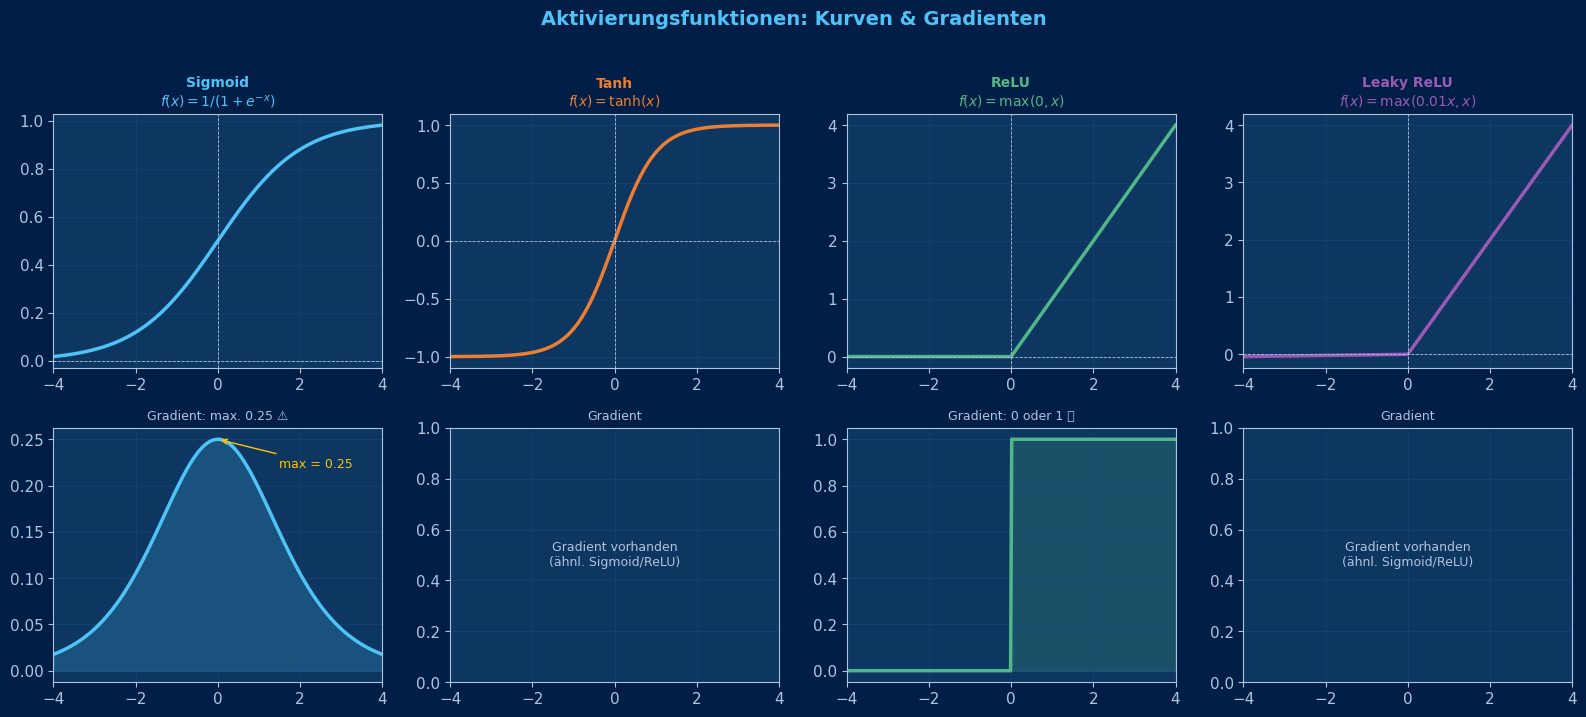


💡 Kernaussagen:
   Sigmoid-Gradient max. 0.25 → "Vanishing Gradient" bei tiefen Netzen.
   ReLU-Gradient 0 oder 1 → kein Schrumpfen → Standard in versteckten Schichten.
   Sigmoid bleibt wichtig für AUSGABESCHICHT → Wert (0,1) als Wahrscheinlichkeit.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 1.1: Aktivierungsfunktionen definieren und visualisieren
# ─────────────────────────────────────────────────────────────────────────────

# x-Werte für die Kurven: 300 gleichmäßige Punkte von -4 bis +4
x = np.linspace(-4, 4, 300)

# ── Die vier Aktivierungsfunktionen ──────────────────────────────────────────

def sigmoid(x):
    # Drückt jeden Wert in (0, 1) – perfekt für Wahrscheinlichkeiten
    # Formel: 1 / (1 + e^(-x))
    return 1 / (1 + np.exp(-x))

def tanh(x):
    # Wie Sigmoid, aber zentriert um 0: Ausgabe zwischen -1 und 1
    return np.tanh(x)

def relu(x):
    # Rectified Linear Unit: negative Werte → 0, positive bleiben
    # np.maximum(0, x): nimmt das Maximum von 0 und x für jeden Wert
    return np.maximum(0, x)

def leaky_relu(x):
    # Wie ReLU, aber negative Werte werden nicht ganz auf 0 gesetzt
    # np.where(bedingung, wenn-wahr, wenn-falsch)
    return np.where(x >= 0, x, 0.01 * x)

# ── Ableitungen (Gradienten) – werden bei Backpropagation gebraucht ──────────

def d_sigmoid(x):
    # Ableitung von Sigmoid: s(x) * (1 - s(x))
    # Maximum: 0.25 bei x=0 → das ist das Vanishing-Gradient-Problem!
    s = sigmoid(x)
    return s * (1 - s)

def d_relu(x):
    # Ableitung von ReLU: 1 wenn x >= 0, sonst 0
    return np.where(x >= 0, 1.0, 0.0)

# ── Visualisierung: 2 Zeilen × 4 Spalten ────────────────────────────────────
funcs = [
    ('Sigmoid',    sigmoid,    C['ice'],    r'$f(x)=1/(1+e^{-x})$'),
    ('Tanh',       tanh,       C['orange'], r'$f(x)=\tanh(x)$'),
    ('ReLU',       relu,       C['green'],  r'$f(x)=\max(0,x)$'),
    ('Leaky ReLU', leaky_relu, C['purple'], r'$f(x)=\max(0.01x,x)$'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Aktivierungsfunktionen: Kurven & Gradienten',
             fontsize=14, color=C['ice'], fontweight='bold', y=1.02)

for col, (name, fn, col_c, formula) in enumerate(funcs):
    # ── Obere Zeile: Funktionskurve ──────────────────────────────────────────
    ax = axes[0, col]
    ax.plot(x, fn(x), color=col_c, lw=2.5)
    ax.axhline(0, color=C['lgray'], lw=0.6, ls='--')   # Nulllinie horizontal
    ax.axvline(0, color=C['lgray'], lw=0.6, ls='--')   # Nulllinie vertikal
    ax.set_title(f'{name}\n{formula}', color=col_c, fontsize=10, fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.grid(True)

    # ── Untere Zeile: Gradient ───────────────────────────────────────────────
    ax2 = axes[1, col]
    if name == 'Sigmoid':
        ax2.plot(x, d_sigmoid(x), color=col_c, lw=2.5)
        ax2.fill_between(x, d_sigmoid(x), alpha=0.2, color=col_c)
        ax2.set_title('Gradient: max. 0.25 ⚠️', color=C['lgray'], fontsize=9)
        ax2.annotate('max = 0.25', xy=(0, 0.25), xytext=(1.5, 0.22),
                     color=C['gold'], fontsize=9,
                     arrowprops=dict(arrowstyle='->', color=C['gold']))
    elif name == 'ReLU':
        ax2.plot(x, d_relu(x), color=col_c, lw=2.5)
        ax2.fill_between(x, d_relu(x), alpha=0.2, color=col_c)
        ax2.set_title('Gradient: 0 oder 1 ✅', color=C['lgray'], fontsize=9)
    else:
        ax2.text(0.5, 0.5, 'Gradient vorhanden\n(ähnl. Sigmoid/ReLU)',
                 ha='center', va='center', color=C['lgray'], fontsize=9,
                 transform=ax2.transAxes)
        ax2.set_title('Gradient', color=C['lgray'], fontsize=9)
    ax2.set_xlim(-4, 4)
    ax2.grid(True)

plt.tight_layout()
plt.show()

print()
print('💡 Kernaussagen:')
print('   Sigmoid-Gradient max. 0.25 → "Vanishing Gradient" bei tiefen Netzen.')
print('   ReLU-Gradient 0 oder 1 → kein Schrumpfen → Standard in versteckten Schichten.')
print('   Sigmoid bleibt wichtig für AUSGABESCHICHT → Wert (0,1) als Wahrscheinlichkeit.')


### 🔍 Was haben wir gesehen?

Die obere Zeile zeigt die **Funktionskurven** — wie jede Funktion Eingabewerte umwandelt.
Die untere Zeile zeigt die **Gradienten** — wie steil die Funktion ist. Bei 4 Schichten mit Sigmoid:
0.25⁴ = **0.4%** des ursprünglichen Lern-Signals. ReLU: 1⁴ = **100%**.

> 🔑 **Merksatz:** ReLU für versteckte Schichten, Sigmoid für die Ausgabeschicht (Wahrscheinlichkeit).


---
## Teil 2 – Einzel-Neuron: Den Forward Pass live nachrechnen

### 🧮 Wie rechnet ein einzelnes Neuron?

Ein Neuron macht exakt zwei Dinge:

**Schritt 1 — Gewichtete Summe:**
```
z = (w₁ × x₁) + (w₂ × x₂) + (w₃ × x₃) + bias
```

**Schritt 2 — Aktivierungsfunktion:**
```
Ausgabe = sigmoid(z)   →   Wert zwischen 0 und 1
```

### Was bedeuten Gewichte?

| Gewicht | Bedeutung |
|---------|-----------|
| **w > 0 (positiv)** | Dieses Feature verstärkt das Signal |
| **w < 0 (negativ)** | Dieses Feature hemmt das Signal |
| **w ≈ 0** | Dieses Feature wird ignoriert |

### Was ist der Bias?

Der Bias ist ein fester Zusatzwert, unabhängig von den Eingaben.
Er verschiebt den Aktivierungspunkt — wie der y-Achsenabschnitt einer Geraden.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SCHRITT 1 – Gewichtete Summe (z):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  z = (w₁ × x₁) + (w₂ × x₂) + (w₃ × x₃) + bias
  z = (0.5 × 0.8) + (-0.2 × 0.3) + (0.9 × 1.0) + 0.1
  z = 0.40 + -0.06 + 0.90 + 0.1
  z = 1.3400

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SCHRITT 2 – Aktivierungsfunktionen:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Sigmoid(1.3400)  = 0.7925  → Wahrscheinlichkeit: 79.2%
  ReLU(1.3400)     = 1.3400

  Entscheidung (Sigmoid, Schwelle 0.5):
  0.7925 > 0.5?  → JA → Klasse 1


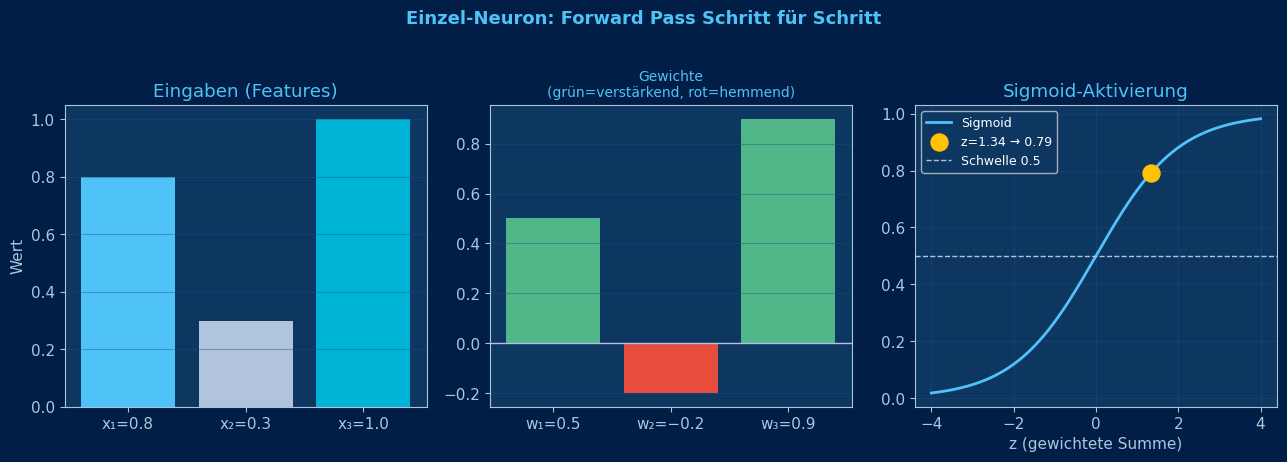


💡 Ein einzelnes Neuron = gewichtete Summe + Aktivierungsfunktion.
   Ein MLP = viele solcher Neuronen, in Schichten organisiert.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 2.1: Forward Pass eines einzelnen Neurons – manuell berechnet
# ─────────────────────────────────────────────────────────────────────────────

# ── Neuron-Parameter ──────────────────────────────────────────────────────────
x_input = np.array([0.8, 0.3, 1.0])    # 3 Eingabe-Features
weights  = np.array([0.5, -0.2, 0.9])  # Gewichte: w1 positiv, w2 hemmend, w3 stark
bias     = 0.1                          # Bias: verschiebt den Aktivierungspunkt

# ── SCHRITT 1: Gewichtete Summe ───────────────────────────────────────────────
# np.dot(a, b): Skalarprodukt = w1*x1 + w2*x2 + w3*x3
z = np.dot(weights, x_input) + bias

print('━' * 55)
print('SCHRITT 1 – Gewichtete Summe (z):')
print('━' * 55)
print(f'  z = (w₁ × x₁) + (w₂ × x₂) + (w₃ × x₃) + bias')
print(f'  z = ({weights[0]} × {x_input[0]}) + ({weights[1]} × {x_input[1]}) + ({weights[2]} × {x_input[2]}) + {bias}')
print(f'  z = {weights[0]*x_input[0]:.2f} + {weights[1]*x_input[1]:.2f} + {weights[2]*x_input[2]:.2f} + {bias}')
print(f'  z = {z:.4f}')
print()

# ── SCHRITT 2: Aktivierungsfunktionen ─────────────────────────────────────────
sig_out  = sigmoid(z)   # Sigmoid: Wert zwischen 0 und 1
relu_out = relu(z)      # ReLU: 0 wenn negativ, sonst z

print('━' * 55)
print('SCHRITT 2 – Aktivierungsfunktionen:')
print('━' * 55)
print(f'  Sigmoid({z:.4f})  = {sig_out:.4f}  → Wahrscheinlichkeit: {sig_out:.1%}')
print(f'  ReLU({z:.4f})     = {relu_out:.4f}')
print()
print(f'  Entscheidung (Sigmoid, Schwelle 0.5):')
print(f'  {sig_out:.4f} > 0.5?  → {"JA → Klasse 1" if sig_out > 0.5 else "NEIN → Klasse 0"}')

# ── Visualisierung ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Einzel-Neuron: Forward Pass Schritt für Schritt',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

# Diagramm 1: Eingabe-Features
axes[0].bar(['x₁=0.8', 'x₂=0.3', 'x₃=1.0'], x_input,
            color=[C['ice'], C['lgray'], C['teal']], edgecolor='none')
axes[0].set_title('Eingaben (Features)', color=C['ice'])
axes[0].set_ylabel('Wert')
axes[0].grid(True, axis='y')

# Diagramm 2: Gewichte (grün = positiv, rot = hemmend)
bar_cols = [C['green'] if w > 0 else C['red'] for w in weights]
axes[1].bar(['w₁=0.5', 'w₂=−0.2', 'w₃=0.9'], weights, color=bar_cols, edgecolor='none')
axes[1].axhline(0, color=C['lgray'], lw=1)
axes[1].set_title('Gewichte\n(grün=verstärkend, rot=hemmend)', color=C['ice'], fontsize=10)
axes[1].grid(True, axis='y')

# Diagramm 3: Sigmoid-Kurve mit berechneten Punkt
xv = np.linspace(-4, 4, 200)
axes[2].plot(xv, sigmoid(xv), color=C['ice'], lw=2, label='Sigmoid')
axes[2].scatter([z], [sig_out], color=C['gold'], s=150, zorder=5,
                label=f'z={z:.2f} → {sig_out:.2f}')
axes[2].axhline(0.5, color=C['lgray'], lw=1, ls='--', label='Schwelle 0.5')
axes[2].set_title('Sigmoid-Aktivierung', color=C['ice'])
axes[2].set_xlabel('z (gewichtete Summe)')
axes[2].legend(fontsize=9)
axes[2].grid(True)

plt.tight_layout()
plt.show()

print()
print('💡 Ein einzelnes Neuron = gewichtete Summe + Aktivierungsfunktion.')
print('   Ein MLP = viele solcher Neuronen, in Schichten organisiert.')


---
## Teil 3 – MLP from Scratch: Das Netz selbst bauen

### 🏗️ Was bedeutet "from Scratch"?

"From Scratch" = von Grund auf, ohne sklearn. Wir implementieren:
1. **Gewichtsmatrizen** (He-Initialisierung)
2. **Forward Pass** (Vorhersage berechnen)
3. **Backward Pass / Backpropagation** (Fehler zurückrechnen)
4. **Gradient Descent Update** (Lernen)

### Architektur

```
Eingabe (4 Features) → Versteckte Schicht (8 Neuronen, ReLU) → Ausgabe (1 Neuron, Sigmoid)
```

### Warum He-Initialisierung?

Alle Gewichte = 0: Alle Neuronen lernen dasselbe (kein Lernen).
Zu groß: Aktivierungen explodieren.
Zu klein: Vanishing Gradient.

**He-Initialisierung** (für ReLU): `W = Zufallszahl × √(2 / Anzahl_Eingaben)` — hält die Signalvarianz konstant.

### Was ist Backpropagation?

Backpropagation berechnet, wie sehr jedes Gewicht zum Gesamtfehler beiträgt.
Es nutzt die **Kettenregel der Differentiation** — rückwärts durch das Netz.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 3.1: Architektur und Gewichtsmatrizen initialisieren
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(42)   # Reproduzierbarkeit: jeder sieht dasselbe Ergebnis

# ── Architektur-Parameter ─────────────────────────────────────────────────────
n_input  = 4    # 4 Eingabe-Features
n_hidden = 8    # 8 Neuronen in der versteckten Schicht
n_output = 1    # 1 Ausgabe-Neuron (binäre Klassifikation)

# ── He-Initialisierung ────────────────────────────────────────────────────────
# np.random.randn(m, n): Zufallszahlen (Normalverteilung, Mittelwert 0)
# * np.sqrt(2.0 / n_input): He-Skalierung für ReLU

# W1: Eingabe (4) → Versteckte Schicht (8) → 4×8 = 32 Parameter
W1 = np.random.randn(n_input, n_hidden) * np.sqrt(2.0 / n_input)
# b1: Bias für jedes versteckte Neuron → 8 Parameter (alle = 0 am Anfang)
b1 = np.zeros((1, n_hidden))

# W2: Versteckte Schicht (8) → Ausgabe (1) → 8 Parameter
W2 = np.random.randn(n_hidden, n_output) * np.sqrt(2.0 / n_hidden)
# b2: Bias für Ausgabe-Neuron → 1 Parameter
b2 = np.zeros((1, n_output))

print('Gewichtsmatrizen des MLP:')
print(f'  W1: {W1.shape}  → Eingabe→Hidden   = {n_input}×{n_hidden} = {n_input*n_hidden} Parameter')
print(f'  b1: {b1.shape}                       = {n_hidden} Parameter')
print(f'  W2: {W2.shape}  → Hidden→Ausgabe   = {n_hidden*n_output} Parameter')
print(f'  b2: {b2.shape}                       = {n_output} Parameter')
print(f'  ─────────────────────────────────')
print(f'  Gesamt: {n_input*n_hidden + n_hidden + n_hidden*n_output + n_output} Parameter')
print()
print('💡 Zum Vergleich: GPT-4 hat ~1 Billion Parameter.')
print('   Unser Netz: 57 Parameter. Trotzdem lernt es binäre Muster.')


Gewichtsmatrizen des MLP:
  W1: (4, 8)  → Eingabe→Hidden   = 4×8 = 32 Parameter
  b1: (1, 8)                       = 8 Parameter
  W2: (8, 1)  → Hidden→Ausgabe   = 8 Parameter
  b2: (1, 1)                       = 1 Parameter
  ─────────────────────────────────
  Gesamt: 49 Parameter

💡 Zum Vergleich: GPT-4 hat ~1 Billion Parameter.
   Unser Netz: 57 Parameter. Trotzdem lernt es binäre Muster.


Daten: 400 Training / 100 Test | 4 Features
MLP from Scratch – Ergebnis nach 200 Epochen:
  Finaler Training-Loss:  0.3082
  Accuracy auf Testdaten: 87.00%


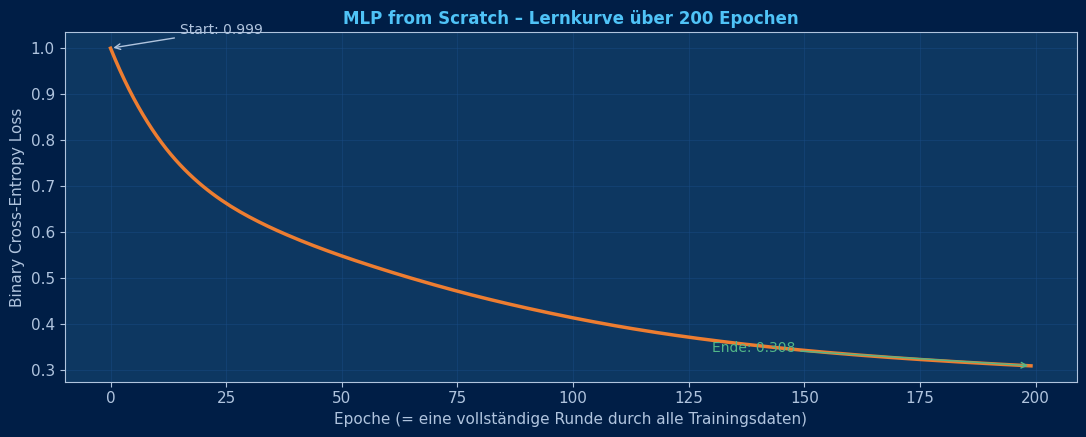


💡 Genau dasselbe passiert in sklearn mlp.fit() – nur verborgen hinter einer Zeile Code.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 3.2: Daten, Forward Pass, Backpropagation, Training Loop
# ─────────────────────────────────────────────────────────────────────────────

# ── Synthetische Daten ────────────────────────────────────────────────────────
# make_classification: erzeugt Zufallsdaten mit klaren Mustern für Klassifikation
X_raw, y_raw = make_classification(
    n_samples=500,     # 500 Datenpunkte
    n_features=4,      # 4 Features (passend zu n_input=4)
    n_informative=3,   # 3 Features tragen zur Klassifikation bei
    n_redundant=1,     # 1 Feature ist Rauschen
    random_state=42
)

X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)   # Anpassen + Anwenden auf Training
X_te_s  = sc.transform(X_te)      # Nur Anwenden auf Test

print(f'Daten: {X_tr_s.shape[0]} Training / {X_te_s.shape[0]} Test | {X_raw.shape[1]} Features')

# ─────────────────────────────────────────────────────────────────────────────
# FORWARD PASS
# Das @ Zeichen = Matrix-Multiplikation in Python/NumPy
# X @ W1: (n×4) @ (4×8) = (n×8) — jeder Datenpunkt mal alle Gewichte
# ─────────────────────────────────────────────────────────────────────────────

def forward(X, W1, b1, W2, b2):
    # Schicht 1: Gewichtete Summe + Bias → ReLU
    Z1 = X @ W1 + b1        # Form: (n, 8)
    A1 = np.maximum(0, Z1)  # ReLU-Aktivierung

    # Schicht 2: Gewichtete Summe + Bias → Sigmoid (Wahrscheinlichkeit)
    Z2 = A1 @ W2 + b2       # Form: (n, 1)
    A2 = sigmoid(Z2)        # Sigmoid → Wert zwischen 0 und 1
    return A1, A2

# ─────────────────────────────────────────────────────────────────────────────
# LOSS-FUNKTION: Binary Cross-Entropy
# Misst, wie weit die Vorhersage von der Wahrheit entfernt ist.
# ─────────────────────────────────────────────────────────────────────────────

def bce_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)  # log(0) vermeiden
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# ─────────────────────────────────────────────────────────────────────────────
# TRAINING LOOP: Forward + Backward + Update
# Eine "Epoche" = einmal alle Trainingsdaten durch das Netz
# ─────────────────────────────────────────────────────────────────────────────

lr       = 0.05    # Lernrate: Schrittgröße beim Gewichts-Update
n_epochs = 200     # Anzahl Trainingsrunden
losses   = []      # Loss pro Epoche aufzeichnen

# Labels als Spaltenvektor: (400,) → (400, 1) — das Netz erwartet Form (n, 1)
y_col = y_tr.reshape(-1, 1)

for epoch in range(n_epochs):

    # ── FORWARD PASS ──────────────────────────────────────────────────────────
    A1, A2 = forward(X_tr_s, W1, b1, W2, b2)
    loss   = bce_loss(y_col, A2)
    losses.append(loss)

    # ── BACKWARD PASS (Backpropagation) ───────────────────────────────────────
    # Berechnet für jedes Gewicht: "Wie sehr trägt es zum Fehler bei?"
    # Das ist der Gradient — zeigt in Richtung wachsender Loss.
    n = X_tr_s.shape[0]

    dA2 = (A2 - y_col) / n       # Fehler der Ausgabe (Vorhersage - Wahrheit)
    dW2 = A1.T @ dA2             # Gradient für W2 (Ausgabeschicht-Gewichte)
    db2 = dA2.sum(axis=0, keepdims=True)

    dA1 = dA2 @ W2.T             # Fehler zurück durch Ausgabeschicht
    dZ1 = dA1 * (A1 > 0)         # Durch ReLU-Ableitung (1 wenn A1>0, sonst 0)
    dW1 = X_tr_s.T @ dZ1         # Gradient für W1 (versteckte Schicht)
    db1 = dZ1.sum(axis=0, keepdims=True)

    # ── GRADIENT DESCENT UPDATE ───────────────────────────────────────────────
    # Neues Gewicht = Altes Gewicht − Lernrate × Gradient
    # Wir gehen entgegen dem Gradienten (bergab im Loss-Gebirge)
    W1 -= lr * dW1;  b1 -= lr * db1
    W2 -= lr * dW2;  b2 -= lr * db2

# ── Evaluation ───────────────────────────────────────────────────────────────
_, A2_test = forward(X_te_s, W1, b1, W2, b2)
y_pred_scratch = (A2_test.flatten() > 0.5).astype(int)  # Schwelle 0.5
acc_scratch    = accuracy_score(y_te, y_pred_scratch)

print(f'MLP from Scratch – Ergebnis nach {n_epochs} Epochen:')
print(f'  Finaler Training-Loss:  {losses[-1]:.4f}')
print(f'  Accuracy auf Testdaten: {acc_scratch:.2%}')

# ── Loss-Kurve ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(losses, color=C['orange'], lw=2.5)
ax.set_xlabel('Epoche (= eine vollständige Runde durch alle Trainingsdaten)')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('MLP from Scratch – Lernkurve über 200 Epochen',
             color=C['ice'], fontsize=12, fontweight='bold')
ax.grid(True)
ax.annotate(f'Start: {losses[0]:.3f}',
            xy=(0, losses[0]), xytext=(15, losses[0]+0.03),
            color=C['lgray'], fontsize=10, arrowprops=dict(arrowstyle='->', color=C['lgray']))
ax.annotate(f'Ende: {losses[-1]:.3f}',
            xy=(len(losses)-1, losses[-1]), xytext=(len(losses)-70, losses[-1]+0.03),
            color=C['green'], fontsize=10, arrowprops=dict(arrowstyle='->', color=C['green']))
plt.tight_layout()
plt.show()

print()
print('💡 Genau dasselbe passiert in sklearn mlp.fit() – nur verborgen hinter einer Zeile Code.')


### 🔍 Was haben wir gerade implementiert?

| Was | Code | Bedeutung |
|-----|------|-----------|
| Forward Pass | `A1, A2 = forward(...)` | Eingabe → Vorhersage |
| Loss | `bce_loss(y_col, A2)` | Wie falsch ist die Vorhersage? |
| Backward Pass | `dW2 = A1.T @ dA2` | Gradienten via Kettenregel |
| Update | `W1 -= lr * dW1` | Gewichte Richtung weniger Fehler |

Das ist **Backpropagation** — der Algorithmus seit 1986, der heute alle neuronalen Netze antreibt.


---
## Teil 4 – Gradient Descent: Im Loss-Gebirge zum Minimum

### ⛰️ Was ist ein Loss-Gebirge?

Wenn man alle möglichen Gewichtswerte einzeichnen würde, entstünde eine hochdimensionale Landschaft —
das **Loss-Gebirge**. Das Training sucht das Tal (Minimum): den Punkt mit dem geringsten Fehler.

**Gradient Descent:** Schaue, wohin es bergab geht, und mache einen Schritt. Wiederholen.

### Die Lernrate η (Eta)

| Lernrate | Effekt |
|----------|--------|
| **Zu groß (0.5)** | Überschießt das Minimum, divergiert |
| **Optimal (0.1)** | Gleichmäßiger Abstieg ins Minimum |
| **Zu klein (0.005)** | Winzige Schritte, braucht 1000× mehr Epochen |

> 💡 In der Praxis: Lernrate mit Learning Rate Scheduler automatisch anpassen.


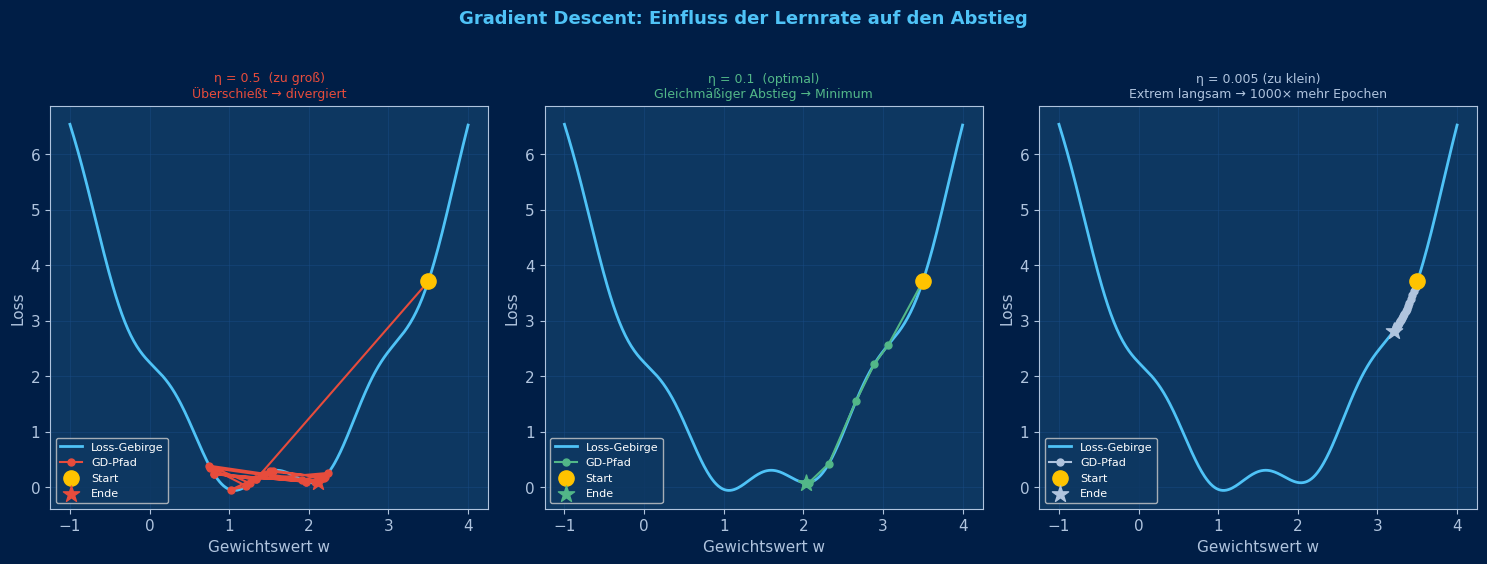


💡 Links (rot):   Zu große Lernrate → springt am Minimum vorbei, divergiert.
   Mitte (grün):  Optimale Lernrate → landet zuverlässig im Minimum.
   Rechts (grau): Zu kleine Lernrate → nach 20 Schritten noch weit weg.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 4.1: Gradient Descent mit drei Lernraten visualisieren
#
# Vereinfachung auf 1 Gewicht (statt tausende) – damit man es zeichnen kann.
# Das Prinzip ist bei jedem Gewicht identisch.
# ─────────────────────────────────────────────────────────────────────────────

def loss_landscape(w):
    # Parabel mit Minimum bei w=1.5, plus Störterm (unebenes Gebirge)
    return (w - 1.5)**2 + 0.3 * np.sin(5 * w)

def grad_landscape(w):
    # Ableitung: Steigung an Punkt w → zeigt bergauf
    return 2 * (w - 1.5) + 1.5 * np.cos(5 * w)

w_vals = np.linspace(-1, 4, 400)

configs = [
    ('η = 0.5  (zu groß)',    0.5,   C['red'],   'Überschießt → divergiert'),
    ('η = 0.1  (optimal)',    0.1,   C['green'], 'Gleichmäßiger Abstieg → Minimum'),
    ('η = 0.005 (zu klein)', 0.005,  C['lgray'], 'Extrem langsam → 1000× mehr Epochen'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle('Gradient Descent: Einfluss der Lernrate auf den Abstieg',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

for ax, (title, lr_v, col, note) in zip(axes, configs):
    # Loss-Gebirge zeichnen
    ax.plot(w_vals, loss_landscape(w_vals), color=C['ice'], lw=2, label='Loss-Gebirge')

    # ── Gradient Descent simulieren ───────────────────────────────────────────
    # Startet bei w=3.5 (rechts oben), macht 20 Schritte
    w_cur = 3.5
    steps_w = [w_cur]
    steps_l = [loss_landscape(w_cur)]

    for _ in range(20):
        # Neues Gewicht = altes − Lernrate × Gradient (entgegen der Steigung)
        w_cur = w_cur - lr_v * grad_landscape(w_cur)
        w_cur = np.clip(w_cur, -1, 4)    # Innerhalb der Grafik bleiben
        steps_w.append(w_cur)
        steps_l.append(loss_landscape(w_cur))

    ax.plot(steps_w, steps_l, 'o-', color=col, ms=5, lw=1.5, label='GD-Pfad')
    ax.scatter([steps_w[0]], [steps_l[0]], color=C['gold'], s=120, zorder=5, label='Start')
    ax.scatter([steps_w[-1]], [steps_l[-1]], color=col, s=150, marker='*', zorder=5, label='Ende')
    ax.set_title(f'{title}\n{note}', color=col, fontsize=9)
    ax.set_xlabel('Gewichtswert w')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

print()
print('💡 Links (rot):   Zu große Lernrate → springt am Minimum vorbei, divergiert.')
print('   Mitte (grün):  Optimale Lernrate → landet zuverlässig im Minimum.')
print('   Rechts (grau): Zu kleine Lernrate → nach 20 Schritten noch weit weg.')


---
## Teil 5 – Overfitting: Wenn das Netz zu viel lernt

### 📚 Was ist Overfitting?

Overfitting = das Modell lernt die Trainingsdaten **auswendig** statt die Muster zu verstehen.
Wie ein Schüler, der alle alten Klausuren auswendig lernt — bei der neuen Klausur versagt er.

**Erkennungszeichen:**
- Training-Loss sinkt weiter ↓
- Validation-Loss beginnt zu **steigen** ↑
- Der wachsende Abstand = Overfitting-Zone

### Lösungen

| Lösung | Beschreibung |
|--------|-------------|
| **Early Stopping** | Stoppe bei bestem Validation-Loss — `early_stopping=True` in sklearn |
| **Regularisierung** | Strafe für große Gewichte (L1/L2) |
| **Dropout** | Neuronen während Training zufällig ausschalten |
| **Mehr Daten** | Mehr Vielfalt → schwieriger auswendig zu lernen |


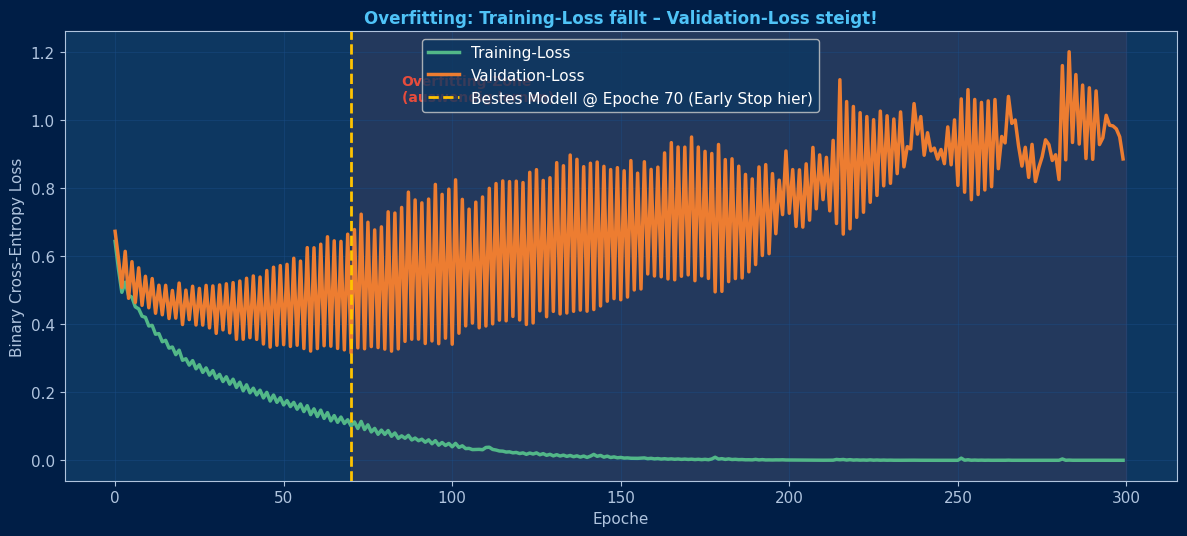

💡 Bester Validation-Loss: Epoche 70
   Training-Loss am Ende:   0.0000  (sehr niedrig → auswendig)
   Validation-Loss am Ende: 0.8860  (höher als bestes → schlimmer!)
   Early Stopping spart 230 unnötige Epochen.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.1: Overfitting absichtlich provozieren
#
# Rezept für garantiertes Overfitting:
# - KLEINER Datensatz (200 Datenpunkte)
# - GROSSES Netz (128-64-32 Neuronen)
# - VIELE Epochen (300)
# ─────────────────────────────────────────────────────────────────────────────

X_small, y_small = make_classification(
    n_samples=200, n_features=10, n_informative=5, random_state=42
)

# Drei-Wege-Split: Training (70%) / Validation (30%)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_small, y_small, test_size=0.3, random_state=42
)
sc2    = StandardScaler()
X_tr2s = sc2.fit_transform(X_tr2)
X_vals = sc2.transform(X_val)

# ── Großes Netz iterativ trainieren ──────────────────────────────────────────
# warm_start=True: Gewichte beim nächsten fit()-Aufruf NICHT zurücksetzen
# max_iter=1: Pro Schleifendurchlauf nur 1 Epoche → Loss nach jeder Epoche messbar
train_losses = []
val_losses   = []
max_ep = 300

model_of = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # Sehr großes Netz für kleinen Datensatz
    max_iter=1, warm_start=True,       # 1 Epoche pro Aufruf
    random_state=42, learning_rate_init=0.01
)

for ep in range(max_ep):
    model_of.fit(X_tr2s, y_tr2)   # 1 Epoche trainieren

    # Wahrscheinlichkeiten für Loss-Berechnung
    p_tr  = np.clip(model_of.predict_proba(X_tr2s)[:, 1], 1e-9, 1-1e-9)
    p_val = np.clip(model_of.predict_proba(X_vals)[:, 1],  1e-9, 1-1e-9)

    # Binary Cross-Entropy manuell berechnen
    tr_loss = -np.mean(y_tr2 * np.log(p_tr)  + (1-y_tr2) * np.log(1-p_tr))
    vl_loss = -np.mean(y_val * np.log(p_val) + (1-y_val) * np.log(1-p_val))
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)

# ── Visualisierung ────────────────────────────────────────────────────────────
best_ep = int(np.argmin(val_losses))   # Epoche mit bestem Validation-Loss

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(train_losses, color=C['green'],  lw=2.5, label='Training-Loss')
ax.plot(val_losses,   color=C['orange'], lw=2.5, label='Validation-Loss')
ax.axvline(best_ep, color=C['gold'], lw=2, ls='--',
           label=f'Bestes Modell @ Epoche {best_ep} (Early Stop hier)')
ax.axvspan(best_ep, max_ep, alpha=0.1, color=C['red'])
ax.text(best_ep + 15, max(val_losses) * 0.88,
        'Overfitting-Zone\n(auswendig lernen)',
        color=C['red'], fontsize=10, fontweight='bold')
ax.set_xlabel('Epoche')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('Overfitting: Training-Loss fällt – Validation-Loss steigt!',
             color=C['ice'], fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f'💡 Bester Validation-Loss: Epoche {best_ep}')
print(f'   Training-Loss am Ende:   {train_losses[-1]:.4f}  (sehr niedrig → auswendig)')
print(f'   Validation-Loss am Ende: {val_losses[-1]:.4f}  (höher als bestes → schlimmer!)')
print(f'   Early Stopping spart {max_ep - best_ep} unnötige Epochen.')


### 🔍 Das klassische Overfitting-Muster

- **Grün (Training):** Fällt kontinuierlich — das Netz lernt die Trainingsdaten immer besser
- **Orange (Validation):** Fällt zunächst, dann **steigt** sie — das Netz generalisiert nicht mehr
- **Goldene Linie:** Optimaler Stoppzeitpunkt — hier sollte Early Stopping eingreifen

> 🔑 **Merksatz:** Ein Modell, das nur auf Trainingsdaten gut ist, ist wertlos.
> Das Ziel ist immer **Generalisierung** — gute Leistung auf ungesehenen Daten.


---
## Teil 6 – 🚔 Challenge: Deepfake-Erkennung

### Was ist ein Deepfake?

KI-generierte Bilder/Videos, die echte Aufnahmen imitieren. Erstellt mit GANs oder Diffusion Models.
KI-generierte Bilder hinterlassen statistisch messbare Spuren:

| Feature | Echte Aufnahme | Deepfake |
|---------|---------------|---------|
| `freq_artifacts` | Niedrig (natürliches Rauschen) | **Hoch** (GAN-Artefakte) |
| `edge_consistency` | **Hoch** (physikalisch konsistent) | Niedriger (generierte Kanten flimmern) |
| `noise_pattern` | ~0.5 (Kamerarauschen) | ~0.3 (geglättet durch Generator) |
| `temporal_delta` | Niedrig (konsistent) | **Höher** (Frameweise Inkonsistenz) |

### Aufgabe

**Ziel: F1-Score (Deepfake-Klasse) > 0.92**

> 💡 **Warum F1 statt Accuracy?** Datensatz: 600 echte, nur 200 Fakes.
> Ein Modell, das immer "Echt" sagt: 75% Accuracy — aber kein einziger Deepfake erkannt. Wertlos.


Deepfake-Datensatz: 800 Bilder gesamt
  Echte Aufnahmen: 600 (75%)
  Deepfakes:       200 (25%)
  → Unbalancierter Datensatz! F1-Score statt Accuracy verwenden.


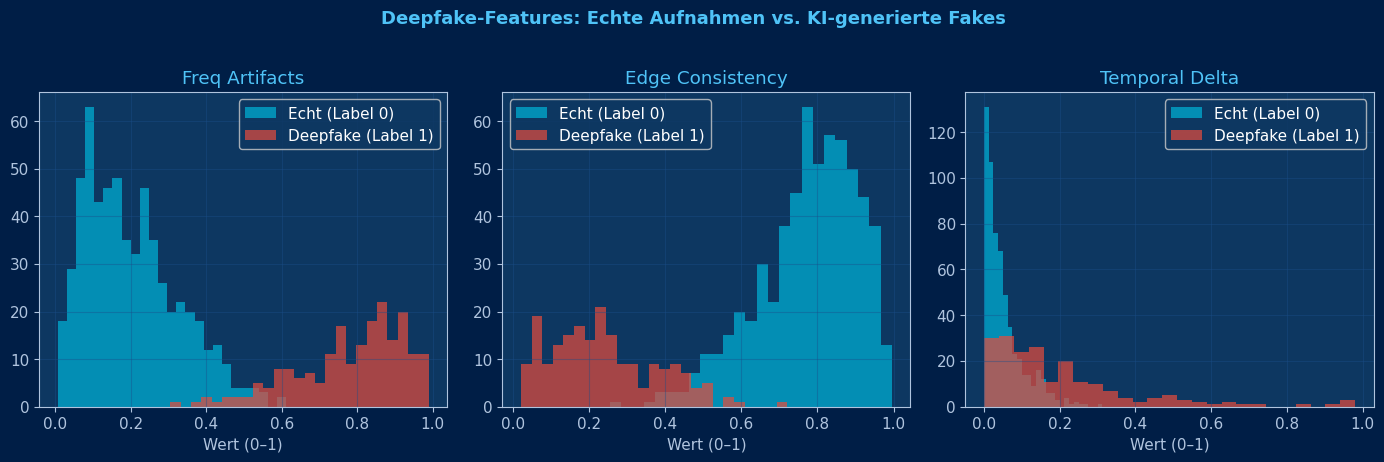


💡 freq_artifacts: Deepfakes (rot) häufen sich rechts → hohe Frequenzartefakte.
   edge_consistency: Echte Bilder (blau) rechts → konsistentere Kanten.
   temporal_delta: Deepfakes rechts → mehr Inkonsistenz zwischen Frames.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 6.1: Deepfake-Datensatz erstellen und visualisieren
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(2024)
n_real, n_fake = 600, 200    # Unbalancierter Datensatz: 3× mehr Echte als Fakes

# ── Echte Aufnahmen ───────────────────────────────────────────────────────────
# np.random.beta(a, b): Werte zwischen 0 und 1
# beta(2, 8): linksverschoben → niedrige Werte häufiger
# beta(7, 2): rechtsverschoben → hohe Werte häufiger
real = pd.DataFrame({
    'freq_artifacts':    np.random.beta(2, 8, n_real),                    # niedrig
    'edge_consistency':  np.random.beta(7, 2, n_real),                    # hoch
    'noise_pattern':     np.random.normal(0.5, 0.12, n_real).clip(0, 1),
    'compression_score': np.random.beta(5, 3, n_real),
    'temporal_delta':    np.random.exponential(0.05, n_real).clip(0, 1),  # niedrig
    'label': 0    # Label 0 = echte Aufnahme
})

# ── KI-generierte Bilder (Deepfakes) ─────────────────────────────────────────
fake = pd.DataFrame({
    'freq_artifacts':    np.random.beta(7, 2, n_fake),                    # HOCH!
    'edge_consistency':  np.random.beta(2, 6, n_fake),                    # niedriger
    'noise_pattern':     np.random.normal(0.3, 0.08, n_fake).clip(0, 1), # geglättet
    'compression_score': np.random.beta(3, 5, n_fake),
    'temporal_delta':    np.random.exponential(0.2, n_fake).clip(0, 1),  # HÖHER!
    'label': 1    # Label 1 = Deepfake
})

# Zusammenführen und mischen (sample mit frac=1 = alle Zeilen, zufällige Reihenfolge)
df_fake   = pd.concat([real, fake], ignore_index=True).sample(frac=1, random_state=42)
feat_fake = ['freq_artifacts', 'edge_consistency', 'noise_pattern',
             'compression_score', 'temporal_delta']

X_f = df_fake[feat_fake].values
y_f = df_fake['label'].values

# stratify=y_f: stellt sicher, dass beide Klassen proportional im Split vertreten sind
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_f, y_f, test_size=0.2, random_state=42, stratify=y_f
)
sc_f    = StandardScaler()
X_tr_fs = sc_f.fit_transform(X_tr_f)
X_te_fs = sc_f.transform(X_te_f)

print(f'Deepfake-Datensatz: {len(df_fake)} Bilder gesamt')
print(f'  Echte Aufnahmen: {(df_fake.label==0).sum()} ({(df_fake.label==0).sum()/len(df_fake):.0%})')
print(f'  Deepfakes:       {(df_fake.label==1).sum()} ({(df_fake.label==1).sum()/len(df_fake):.0%})')
print(f'  → Unbalancierter Datensatz! F1-Score statt Accuracy verwenden.')

# ── Feature-Verteilungen ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Deepfake-Features: Echte Aufnahmen vs. KI-generierte Fakes',
             color=C['ice'], fontsize=13, fontweight='bold', y=1.02)

for ax, fn in zip(axes, ['freq_artifacts', 'edge_consistency', 'temporal_delta']):
    ax.hist(df_fake.loc[df_fake.label == 0, fn], bins=25, alpha=0.7,
            color=C['teal'], label='Echt (Label 0)')
    ax.hist(df_fake.loc[df_fake.label == 1, fn], bins=25, alpha=0.7,
            color=C['red'],  label='Deepfake (Label 1)')
    ax.set_title(fn.replace('_', ' ').title(), color=C['ice'])
    ax.set_xlabel('Wert (0–1)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

print()
print('💡 freq_artifacts: Deepfakes (rot) häufen sich rechts → hohe Frequenzartefakte.')
print('   edge_consistency: Echte Bilder (blau) rechts → konsistentere Kanten.')
print('   temporal_delta: Deepfakes rechts → mehr Inkonsistenz zwischen Frames.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DEEPFAKE-ERKENNUNG: ERGEBNIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy:            97.50%
  F1-Score (Deepfake): 0.951
  ✅  Ziel erreicht! F1 > 0.92

Detaillierter Bericht:
              precision    recall  f1-score   support

        Echt       0.99      0.97      0.98       120
    Deepfake       0.93      0.97      0.95        40

    accuracy                           0.97       160
   macro avg       0.96      0.97      0.97       160
weighted avg       0.98      0.97      0.98       160



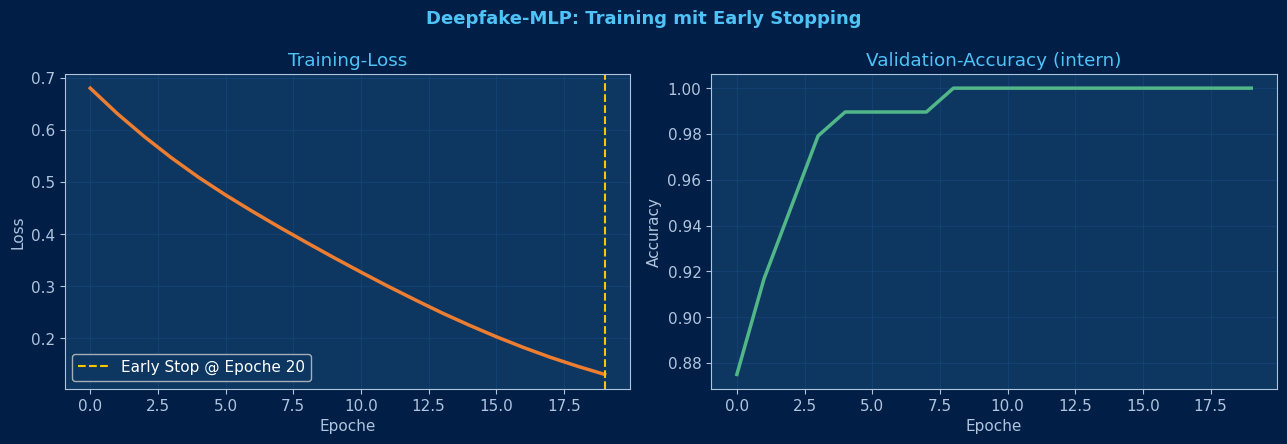

💡 Early Stopping: gestoppt nach 20 Epochen (max wäre 500).
   Spart Zeit und verhindert Overfitting – automatisch.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 6.2: MLP mit Early Stopping trainieren – Ziel: F1-Score > 0.92
# ─────────────────────────────────────────────────────────────────────────────

mlp_fake = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # Zwei versteckte Schichten
    activation='relu',            # ReLU in versteckten Schichten
    max_iter=500,                 # Maximal 500 Epochen

    # ── Early Stopping ────────────────────────────────────────────────────────
    early_stopping=True,          # Aktiviert! Stoppt bei Stagnation
    validation_fraction=0.15,     # 15% der Trainingsdaten als internes Validation-Set
    n_iter_no_change=10,          # Stoppe wenn 10 Epochen keine Verbesserung

    random_state=42
)

mlp_fake.fit(X_tr_fs, y_tr_f)   # Trainieren

# ── Evaluation ───────────────────────────────────────────────────────────────
y_pred_fake = mlp_fake.predict(X_te_fs)
f1_fake     = f1_score(y_te_f, y_pred_fake, pos_label=1)   # F1 für Deepfake-Klasse
acc_fake    = accuracy_score(y_te_f, y_pred_fake)
status      = '✅  Ziel erreicht! F1 > 0.92' if f1_fake > 0.92 else '⚠️  Noch nicht – Hyperparameter anpassen!'

print('━' * 55)
print('  DEEPFAKE-ERKENNUNG: ERGEBNIS')
print('━' * 55)
print(f'  Accuracy:            {acc_fake:.2%}')
print(f'  F1-Score (Deepfake): {f1_fake:.3f}')
print(f'  {status}')
print()
print('Detaillierter Bericht:')
print(classification_report(y_te_f, y_pred_fake, target_names=['Echt', 'Deepfake']))

# ── Loss-Kurve mit Early Stopping ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Deepfake-MLP: Training mit Early Stopping',
             color=C['ice'], fontsize=13, fontweight='bold')

axes[0].plot(mlp_fake.loss_curve_, color=C['orange'], lw=2.5)
axes[0].axvline(len(mlp_fake.loss_curve_)-1, color=C['gold'], ls='--', lw=1.5,
                label=f'Early Stop @ Epoche {len(mlp_fake.loss_curve_)}')
axes[0].set_title('Training-Loss', color=C['ice'])
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mlp_fake.validation_scores_, color=C['green'], lw=2.5)
axes[1].set_title('Validation-Accuracy (intern)', color=C['ice'])
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'💡 Early Stopping: gestoppt nach {len(mlp_fake.loss_curve_)} Epochen (max wäre 500).')
print('   Spart Zeit und verhindert Overfitting – automatisch.')


### 🔍 Reflexion: Was haben wir bei der Deepfake-Erkennung gelernt?

1. **Unbalancierte Datensätze** brauchen F1-Score, nicht Accuracy
2. **Early Stopping** stoppt automatisch — kein manuelles Epochen-Tuning nötig
3. **Forensische Perspektive:** Die verwendeten Features entsprechen realen forensischen
   Merkmalen aus der Deepfake-Erkennung (S3.1 vertieft das mit echten Bilddaten)

> 🔑 **Kernaussage:** ML-basierte Deepfake-Erkennung ist machbar — aber kein Allheilmittel.
> Generatoren werden besser. Das ist ein Wettrüsten, kein gelöstes Problem.


---
## 📋 Zusammenfassung

| Konzept | Implementiert | Forensische Relevanz |
|---------|--------------|---------------------|
| **Aktivierungsfunktionen** | Sigmoid, ReLU, Tanh, Leaky ReLU + Gradienten | ReLU = Standard; Sigmoid = Ausgabe |
| **Forward Pass (Neuron)** | Gewichtete Summe + Aktivierung manuell | Grundbaustein jedes neuronalen Netzes |
| **MLP from Scratch** | Forward + Backward + Gradient Descent | Verstehen, was sklearn verbirgt |
| **Gradient Descent** | Drei Lernraten im Vergleich | Lernrate als kritischer Hyperparameter |
| **Overfitting** | Loss-Kurven Divergenz visualisiert | Modell muss generalisieren, nicht auswendig lernen |
| **Deepfake-Erkennung** | F1 > 0.92 + Early Stopping | Reale forensische Anwendung (S3.1) |

---

### 🔗 Was verbindet NB-01 und NB-02?

| NB-01 (sklearn Black Box) | NB-02 (from Scratch transparent) |
|---------------------------|----------------------------------|
| `mlp.fit(X, y)` | Forward + Backward Loop (200 Zeilen) |
| Loss-Kurve sinkt automatisch | Loss sinkt durch Backpropagation + GD |
| `accuracy_score(...)` | Gleiche Metrik, manuell berechnet |
| Man sieht nur Ergebnis | Man sieht jeden Rechenschritt |

---

### 🏁 Nächste Schritte

| Notebook | Inhalt |
|----------|--------|
| **NB-03** (S1.4) | Ensemble-Methoden: Random Forest & XGBoost |
| **NB-06** (S2.3) | LLM Fine-Tuning: Transfer Learning |
| **NB-09** (S3.1) | Deepfake-Erkennung mit echten Bild-Features |

---

> **KI Advanced · IA1017000 · Hochschule für Polizei Baden-Württemberg**
